# 9. Euler's rule, errors, and timesteps

Last time we got to solve ODEs for a single variable. 

$ \frac{d x(t)}{dt} = v $ with the initial condition $ x(0)=1 $ m. The velocity $v$ is a constant 1 m/s.

Our most recent code looks like this:

Text(0, 0.5, 'x position')

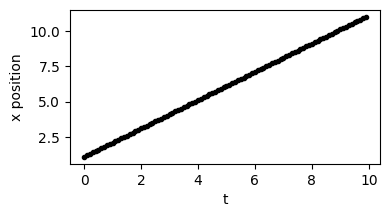

In [2]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
t_range = np.arange(0,10,dt)

xpos = 1
xvel = 1
xpos_list = []

def move(xpos,xvel,dt):
    xpos += xvel * dt
    return xpos, xvel

for t in t_range:
    xpos, xvel = move(xpos, xvel, dt)
    xpos_list.append(xpos)

plt.figure(figsize=(4,2))    
plt.plot(t_range, xpos_list, 'k.')
plt.xlabel('t')
plt.ylabel('x position')

Now that we can solve ODEs for a single variable, we can easily extend that to **multiple independent variables**.

$ \frac{d x_1(t)}{dt} = v_1 $

$ \frac{d x_2(t)}{dt} = v_2 $ 

with some initial conditions. It'll be simply doubling the amount of work and writing another set of equations in the code for $ x_2 $ so we won't go through it here.

We can now move on to 2nd order differential equations.

$ \frac{d^2 z(t)}{dt^2} = -g $ 

You may have already guessed where we are going with this – this just Newton's equations for a particle doing free fall. Of course, we haven't solved a 2nd order ODE yet. But we can break it up into two **coupled** 1st order ODEs involving  two **dependent** variables $ z $ and $ v_z $. 

$ \frac{d z(t)}{dt} = v_z(t) $

$ \frac{d v_z(t)}{dt} = -g $ 
    

Of course, we two variables to solve for, we need to set two initial conditions. Let's set $ z(0)=1 $ and $ v_z(0)=0 $. 

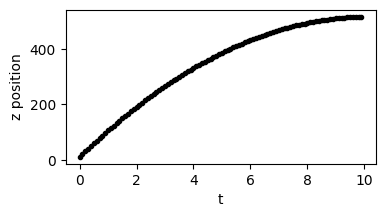

In [1]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
t_range = np.arange(0,10,dt)

zpos = 1
zvel = 100
zpos_list = []
zvel_list = []
g = -9.8

def move(zpos,zvel,dt):
    zpos += zvel * dt
    zvel += g*dt
    return zpos, zvel

for t in t_range:
    zpos, zvel = move(zpos, zvel, dt)
    zpos_list.append(zpos)
    zvel_list.append(zvel)

plt.figure(figsize=(4,2))    
plt.plot(t_range, zpos_list, 'k.')
plt.xlabel('t')
plt.ylabel('z position')
plt.show()

## Hands-on: Trajectory of projectile under gravity

Next let's try the example of a projectile thrown from the origin, and plot z versus x. With initial conditions 
$ x(0)=z(0) = 0 $, 
$ v_x(0)=3 $ m/s and 
$ v_z=10 $ m/s.

In [16]:
def move(pos, vel):
    pos[0] += vel[0] * dt
    pos[1] += vel[1] * dt
    vel[1] += g * dt
    return pos, vel

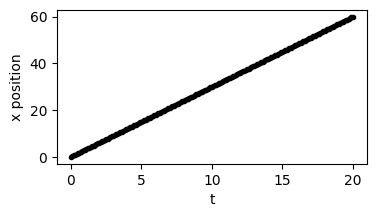

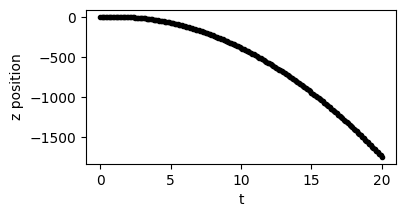

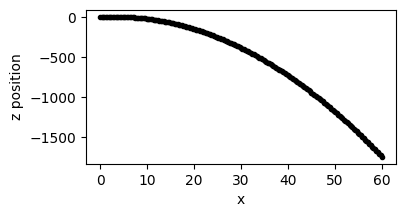

In [18]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
# include the endpoint so t_range has the same length as pos_list (initial + steps)
t_range = np.arange(0, 20 + dt, dt)

xpos = 0
xvel = 3

zpos = 0
zvel = 10

pos_list = [[xpos, zpos]]
vel_list = [[xvel, zvel]]

g = -9.8

for t in t_range:
    pos = pos_list[-1].copy()
    vel = vel_list[-1].copy()
    pos, vel = move(pos, vel)
    pos_list.append(pos)
    vel_list.append(vel)

# remove the extra appended element (pop in-place) so lengths match t_range
pos_list.pop()
vel_list.pop()

plt.figure(figsize=(4,2))    
plt.plot(t_range, [p[0] for p in pos_list], 'k.')
plt.xlabel('t')
plt.ylabel('x position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot(t_range, [p[1] for p in pos_list], 'k.')
plt.xlabel('t')
plt.ylabel('z position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot([p[0] for p in pos_list], [p[1] for p in pos_list], 'k.')
plt.xlabel('x')
plt.ylabel('z position')
plt.show()


# Could we add bouncing to the particle's trajectory?

In [22]:
def move_with_bounce(pos, vel):
    pos[0] += vel[0] * dt
    pos[1] += vel[1] * dt
    vel[1] += g * dt
    if pos[1] < 0:
        vel[1] = -vel[1]
    return pos, vel

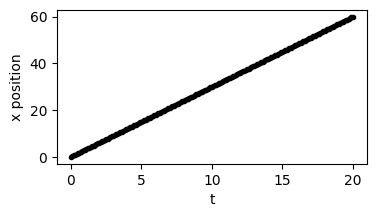

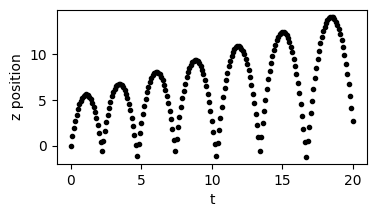

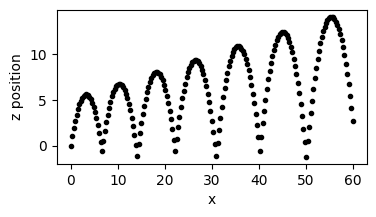

In [23]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
# include the endpoint so t_range has the same length as pos_list (initial + steps)
t_range = np.arange(0, 20 + dt, dt)

xpos = 0
xvel = 3

zpos = 0
zvel = 10

pos_list = [[xpos, zpos]]
vel_list = [[xvel, zvel]]

g = -9.8

for t in t_range:
    pos = pos_list[-1].copy()
    vel = vel_list[-1].copy()
    pos, vel = move_with_bounce(pos, vel)
    pos_list.append(pos)
    vel_list.append(vel)

# remove the extra appended element (pop in-place) so lengths match t_range
pos_list.pop()
vel_list.pop()

plt.figure(figsize=(4,2))    
plt.plot(t_range, [p[0] for p in pos_list], 'k.')
plt.xlabel('t')
plt.ylabel('x position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot(t_range, [p[1] for p in pos_list], 'k.')
plt.xlabel('t')
plt.ylabel('z position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot([p[0] for p in pos_list], [p[1] for p in pos_list], 'k.')
plt.xlabel('x')
plt.ylabel('z position')
plt.show()


# Checking against analytic solution; energy conservation

$$x(t) = v_{0x} t$$
$$z(t) = v_{0z} t - \frac{1}{2}gt^2$$

In [20]:
def x_analytic(t):
    return xvel * t

def z_analytic(zvel, t, shift):
    return zvel * (t-shift) + 0.5 * g * (t-shift)**2

def zvel_analytic(zvel,t, shift):
    return zvel + g * (t-shift)

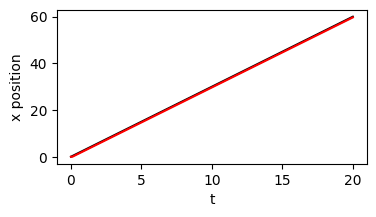

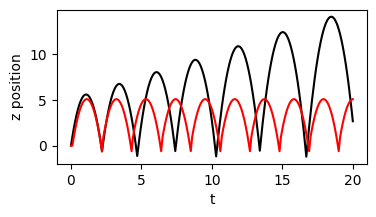

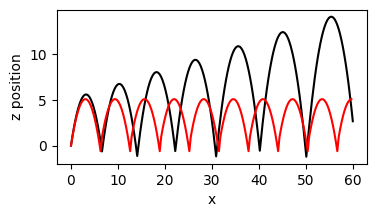

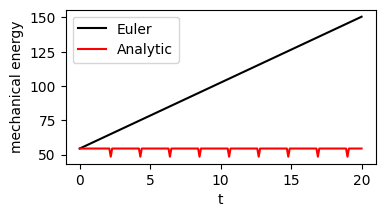

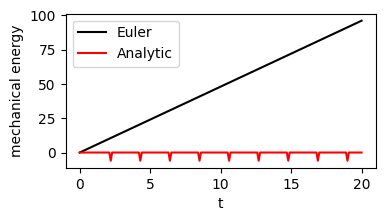

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def x_analytic(t):
    return xvel * t

def z_analytic(zvel, t, shift):
    return zvel * (t-shift) + 0.5 * g * (t-shift)**2

def zvel_analytic(zvel,t, shift):
    return zvel + g * (t-shift)

def mechanical_energy(pos, vel):
    return 0.5 * (vel[0]**2 + vel[1]**2) - g * pos[1]

dt = 0.1
# include the endpoint so t_range has the same length as pos_list (initial + steps)
t_range = np.arange(0, 20 + dt, dt)

g = -9.8

xpos = 0
xvel = 3

zpos = 0
zvel = 10

pos_list = [[xpos, zpos]]
vel_list = [[xvel, zvel]]
energy_list = [mechanical_energy(pos_list[0], vel_list[0])]

pos_list_analytic = pos_list.copy()
vel_list_analytic = vel_list.copy()
energy_list_analytic = energy_list.copy()


shift = 0
for t in t_range:
    pos_list_analytic.append([x_analytic(t), z_analytic(zvel, t, shift)])
    vel_list_analytic.append([xvel, zvel_analytic(zvel, t, shift)])
    if pos_list_analytic[-1][1] < 0:
        shift = t
        vel_list_analytic[-1][1] = zvel
    energy_list_analytic.append(mechanical_energy(pos_list_analytic[-1], vel_list_analytic[-1]))

for t in t_range:
    pos = pos_list[-1].copy()
    vel = vel_list[-1].copy()
    pos, vel = move_with_bounce(pos, vel)
    pos_list.append(pos)
    vel_list.append(vel)
    energy_list.append(mechanical_energy(pos, vel))

# remove the extra appended element (pop in-place) so lengths match t_range
pos_list.pop()
vel_list.pop()
pos_list_analytic.pop()
vel_list_analytic.pop()
energy_list.pop()
energy_list_analytic.pop()

plt.figure(figsize=(4,2))    
plt.plot(t_range, [p[0] for p in pos_list], 'k-')
plt.plot(t_range, [p[0] for p in pos_list_analytic], 'r-')
plt.xlabel('t')
plt.ylabel('x position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot(t_range, [p[1] for p in pos_list], 'k-')
plt.plot(t_range, [p[1] for p in pos_list_analytic], 'r-')
plt.xlabel('t')
plt.ylabel('z position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot([p[0] for p in pos_list], [p[1] for p in pos_list], 'k-')
plt.plot([p[0] for p in pos_list_analytic], [p[1] for p in pos_list_analytic], 'r-')
plt.xlabel('x')
plt.ylabel('z position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot(t_range, energy_list, 'k-', label='Euler')
plt.plot(t_range, energy_list_analytic, 'r-', label='Analytic')
plt.xlabel('t')
plt.ylabel('mechanical energy')
plt.legend()
plt.show()

plt.figure(figsize=(4,2))    
plt.plot(t_range, np.array(energy_list) - energy_list[0], 'k-', label='Euler')
plt.plot(t_range, np.array(energy_list_analytic) - energy_list_analytic[0], 'r-', label='Analytic')
plt.xlabel('t')
plt.ylabel('mechanical energy')
plt.legend()
plt.show()

## **Euler's Rule**

Explain that Euler's method is the simplest numerical integration scheme:
- It uses the derivative at the current point to linearly extrapolate to the next point
- Formula: $x_{n+1} = x_n + v_x \cdot dt$ and $v_{n+1} = v_n + a_x \cdot dt$
- It assumes the derivative (velocity, acceleration) remains constant over the timestep
- This is only accurate for infinitesimally small $dt$

## **Taylor Expansion Analysis**

Show why Euler's method has error by comparing to the exact solution via Taylor series:

$$x(t + dt) = x(t) + \frac{dx}{dt}dt + \frac{1}{2}\frac{d^2x}{dt^2}dt^2 + O(dt^3)$$

Euler's method only keeps the first two terms: $x(t + dt) \approx x(t) + v_x \cdot dt$

The error per step comes from neglecting the $\frac{1}{2}a_x \cdot dt^2$ term and higher-order terms.

## **Local vs Global Error**

**Local error** (error in a single step):
- For Euler's method: $O(dt^2)$ — the error in one timestep is proportional to $dt^2$
- This is the truncation error from the Taylor series

**Global error** (accumulated error after many steps):
- To go from time $0$ to time $T$, you need $N = T/dt$ steps
- Errors accumulate over $N$ steps: Global error $\sim N \times dt^2 = \frac{T}{dt} \times dt^2 = O(dt)$
- So Euler's method is **first-order accurate** globally

This explains why energy increases systematically — the $O(dt)$ error accumulates coherently over the trajectory, causing a systematic drift rather than random fluctuations.


<div class="span alert alert-success">

## Choosing step size according to the physical problem
    
- Step too big = larger error
- Step too small = computational waste
    

The size of the timestep should be small. But what is small? Compared to what? 

The timestep $\Delta t$ should be much smaller compared to the **characteristic timescale $\bf\tau$** of the problem, $\Delta t << \tau$. What is this timescale then? 

**Exmaple 1.** For throwing a ball in the air, $\tau$ would be the time the ball travels in the air before hitting the ground. 

**Exmaple 2.** For earth revolving around the sun, $\tau$ is on the order of a year. 

**Exmaple 3.** For simulating molecules floating around not reacting with each other, $\tau$ is on the order of phonon vibration periods, which is picoseconds = $10^{-9}$s.
    
A rule of thumb is to use $\Delta t = 0.01 \tau$.

</div>

In our case, how long before the first bounce?  Multiply that by 0.01 and see if the results are better.

# Forward and Backwards Differences $ \Rightarrow $ Central Difference?

In [25]:
def move_forward_diff(pos, vel):
    pos[0] += vel[0] * dt
    pos[1] += vel[1] * dt
    vel[1] += g * dt
    return pos, vel

def move_backward_diff(pos, vel):
    pos[0] += vel[0] * dt
    vel[1] += g * dt
    pos[1] += vel[1] * dt
    return pos, vel

# Rewriting for trajectory without bouncing only using 1d lists/arrays

In [30]:
def move_in_one_dim(pos, vel, constant_vel):
    if constant_vel:
        pos += vel * dt
    else:
        pos += vel * dt
        vel += g * dt
    return pos, vel

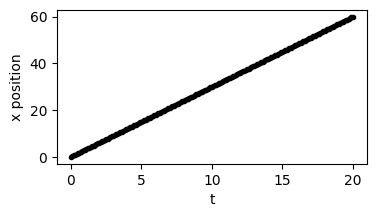

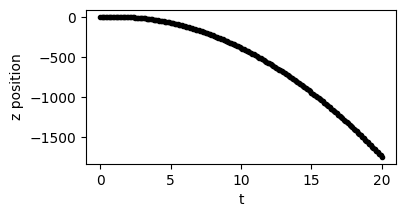

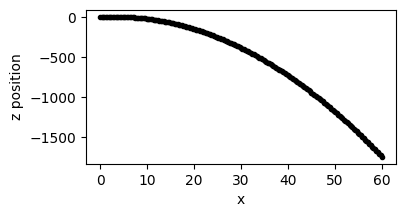

In [32]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
# include the endpoint so t_range has the same length as pos_list (initial + steps)
t_range = np.arange(0, 20 + dt, dt)

xpos = 0
xvel = 3

zpos = 0
zvel = 10

xpos_list = [xpos]
zpos_list = [zpos]
xvel_list = [xvel]
zvel_list = [zvel]

g = -9.8

for t in t_range:
    xpos, xvel = move_in_one_dim(xpos, xvel, True)
    zpos, zvel = move_in_one_dim(zpos, zvel, False)
    xpos_list.append(xpos)
    zpos_list.append(zpos)
    xvel_list.append(xvel)
    zvel_list.append(zvel)

# remove the extra appended element (pop in-place) so lengths match t_range
xpos_list.pop()
zpos_list.pop()
xvel_list.pop()
zvel_list.pop()

plt.figure(figsize=(4,2))    
plt.plot(t_range, xpos_list, 'k.')
plt.xlabel('t')
plt.ylabel('x position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot(t_range, zpos_list, 'k.')
plt.xlabel('t')
plt.ylabel('z position')
plt.show()

plt.figure(figsize=(4,2))    
plt.plot(xpos_list, zpos_list, 'k.')
plt.xlabel('x')
plt.ylabel('z position')
plt.show()